In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shwetabh123/mall-customers/Mall_Customers.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# Pre - Processing

In [3]:
df = pd.read_csv('/kaggle/input/datasets/shwetabh123/mall-customers/Mall_Customers.csv')

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-MEANS CLUSTERING
#### with 2 column

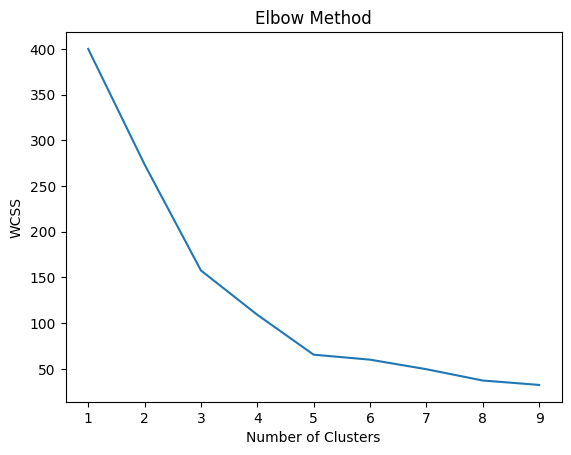

In [8]:
# Find Optimal K (Elbow Method)
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

In [10]:
print("KMeans Score:", silhouette_score(X_scaled, y_kmeans))

KMeans Score: 0.5546571631111091


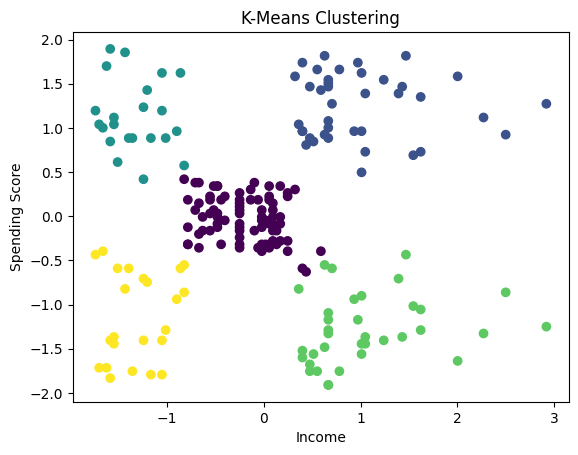

In [11]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

# DBSCAN CLUSTERING
#### with 2 column

In [12]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

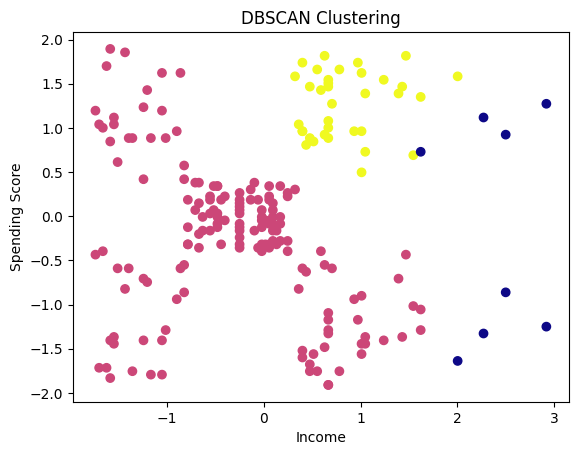

In [13]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_dbscan, cmap='plasma')
plt.title("DBSCAN Clustering")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

In [14]:

print("DBSCAN Score:", silhouette_score(X_scaled, y_dbscan))

DBSCAN Score: 0.35044619989666004


# PCA

In [15]:
# Drop CustomerID (not useful for clustering)
df = df.drop(['CustomerID'], axis=1)

# Convert Gender to numeric
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

# Final feature set
X = df
X

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40
...,...,...,...,...
195,1,35,120,79
196,1,45,126,28
197,0,32,126,74
198,0,32,137,18


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.33690046 0.26230645]


In [18]:
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Total Variance Retained: 0.5992069019819846


# K-MEANS with 2 PCA component

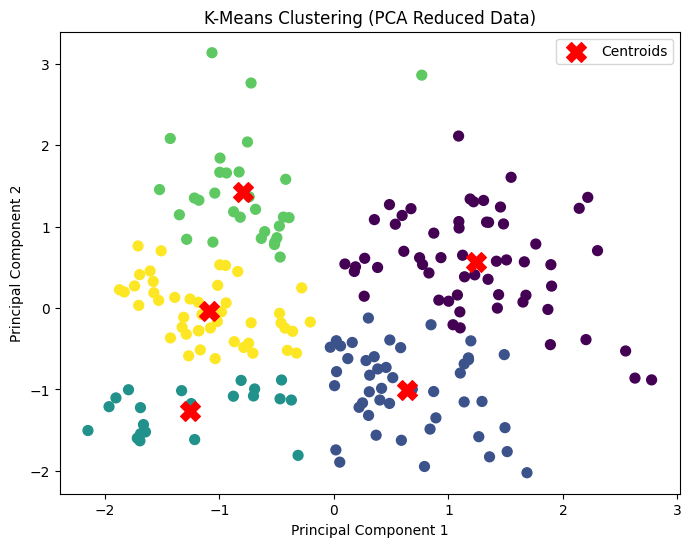

In [19]:
# K-MEANS ON PCA DATA
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_pca)
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=50)

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            color='red', s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering (PCA Reduced Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

# DBSCAN with 2 PCA component

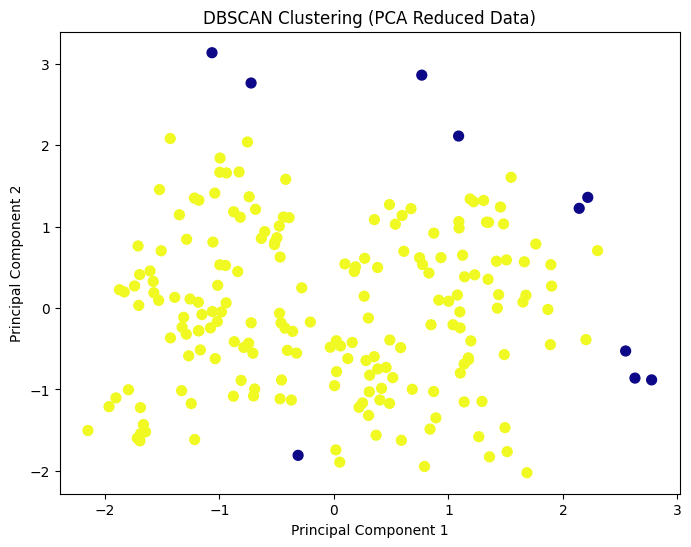

In [20]:
# DBSCAN ON PCA DATA
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_pca)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_dbscan, cmap='plasma', s=50)

plt.title("DBSCAN Clustering (PCA Reduced Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [21]:
print("KMeans Score:", silhouette_score(X_scaled, y_kmeans))
print("DBSCAN Score:", silhouette_score(X_scaled, y_dbscan))

KMeans Score: 0.1993525346871192
DBSCAN Score: 0.2162792628694187


# Apply PCA (3 Components)

In [22]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.33690046 0.26230645 0.23260639]
Total Variance: 0.831813287884595


# K-MEANS with 3 PCA component

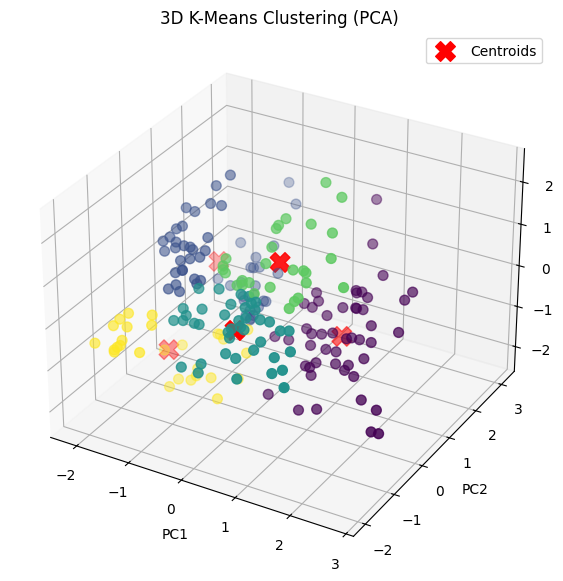

In [23]:
# K-MEANS
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
           c=y_kmeans, cmap='viridis', s=50)

# Plot centroids
centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2],
           c='red', s=200, marker='X', label='Centroids')

ax.set_title("3D K-Means Clustering (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.legend()
plt.show()

# DBSCAN with 3 PCA component

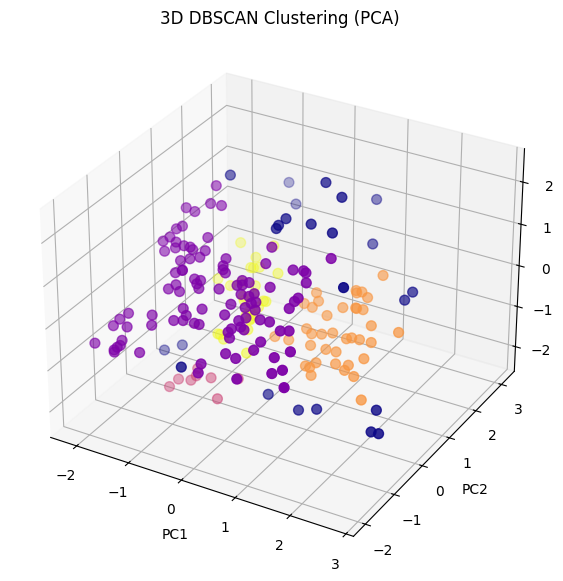

In [24]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
y_dbscan = dbscan.fit_predict(X_pca)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
           c=y_dbscan, cmap='plasma', s=50)

ax.set_title("3D DBSCAN Clustering (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

In [25]:
print("KMeans Score:", silhouette_score(X_scaled, y_kmeans))
print("DBSCAN Score:", silhouette_score(X_scaled, y_dbscan))

KMeans Score: 0.24440372934873478
DBSCAN Score: 0.19704174267728558
